Importation des libraires

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

import joblib
import warnings
warnings.filterwarnings("ignore")


Chargement dataset

In [3]:
df = pd.read_csv('telecom_customer_churn.csv')
df.head(10)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,...,Credit Card,69.40,571.45,0.00,0,150.93,722.38,Stayed,NaN,NaN
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,...,Bank Withdrawal,109.70,7904.25,0.00,0,707.16,8611.41,Stayed,NaN,NaN
7,0014-BMAQU,Male,52,Yes,0,Napa,94558,38.489789,-122.270110,8,...,Credit Card,84.65,5377.80,0.00,20,816.48,6214.28,Stayed,NaN,NaN
8,0015-UOCOJ,Female,68,No,0,Simi Valley,93063,34.296813,-118.685703,0,...,Bank Withdrawal,48.20,340.35,0.00,0,73.71,414.06,Stayed,NaN,NaN
9,0016-QLJIS,Female,43,Yes,1,Sheridan,95681,38.984756,-121.345074,3,...,Credit Card,90.45,5957.90,0.00,0,1849.90,7807.80,Stayed,NaN,NaN


## Présentation du dataset

Ce jeu de données provient d’une entreprise de télécommunications et contient
des informations démographiques, contractuelles et comportementales des clients.

Objectif :
Prédire si un client va quitter l’entreprise (Churn).

Variable cible :
Customer Status → transformée en variable binaire :
- 1 : Churn
- 0 : No Churn

Analyse préliminaire du dataset

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


Vérification des valeurs manquantes

In [5]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

Remplacement des valeurs manquantes par la méthode appropriée

In [6]:
# 1) Offer : les NA signifient généralement "aucune offre"
df["Offer"] = df["Offer"].fillna("No Offer")

# 2) Variables liées à Internet : dans ce dataset, les NA correspondent aux clients sans service Internet
internet_cat = [
    "Internet Type","Online Security","Online Backup",
    "Device Protection Plan","Premium Tech Support",
    "Streaming TV","Streaming Movies","Streaming Music",
    "Unlimited Data"
]
for col in internet_cat:
    df[col] = df[col].fillna("No Internet Service")

# 3) Download : si pas d'internet, volume = 0
df["Avg Monthly GB Download"] = df["Avg Monthly GB Download"].fillna(0)

# 4) Téléphone : les NA de Multiple Lines correspondent aux clients sans service téléphonique
df["Multiple Lines"] = df["Multiple Lines"].fillna("No Phone Service")

# 5) Long distance charges : si pas de téléphone, charges = 0
df["Avg Monthly Long Distance Charges"] = df["Avg Monthly Long Distance Charges"].fillna(0)

# Vérification
df.isnull().sum()


Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                           0
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                  

Suppression des colonnes inutiles.

In [7]:
# Suppression des colonnes inutiles
df.drop(columns=["Customer ID", "Churn Category", "Churn Reason"], inplace=True)

df.columns


Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code',
       'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months',
       'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges',
       'Multiple Lines', 'Internet Service', 'Internet Type',
       'Avg Monthly GB Download', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Monthly Charge',
       'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Customer Status'],
      dtype='object')

## Création de la variable cible (Churn)
On prédit si le client **churne** (1) ou non (0) à partir de `Customer Status`.


In [8]:
# Target binaire : 1 si Churned, sinon 0
df["Churn"] = (df["Customer Status"] == "Churned").astype(int)

# On supprime la colonne d'origine pour éviter de l'utiliser comme feature
df.drop(columns=["Customer Status"], inplace=True)

df["Churn"].value_counts(normalize=True)


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

## Analyse exploratoire rapide (EDA)
Quelques visualisations utiles pour comprendre le churn.


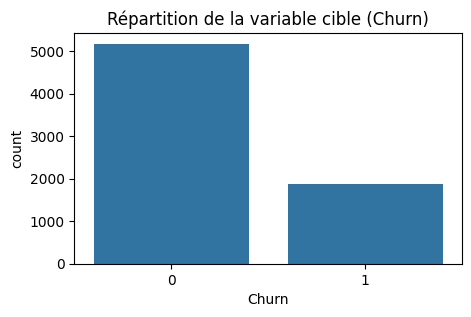

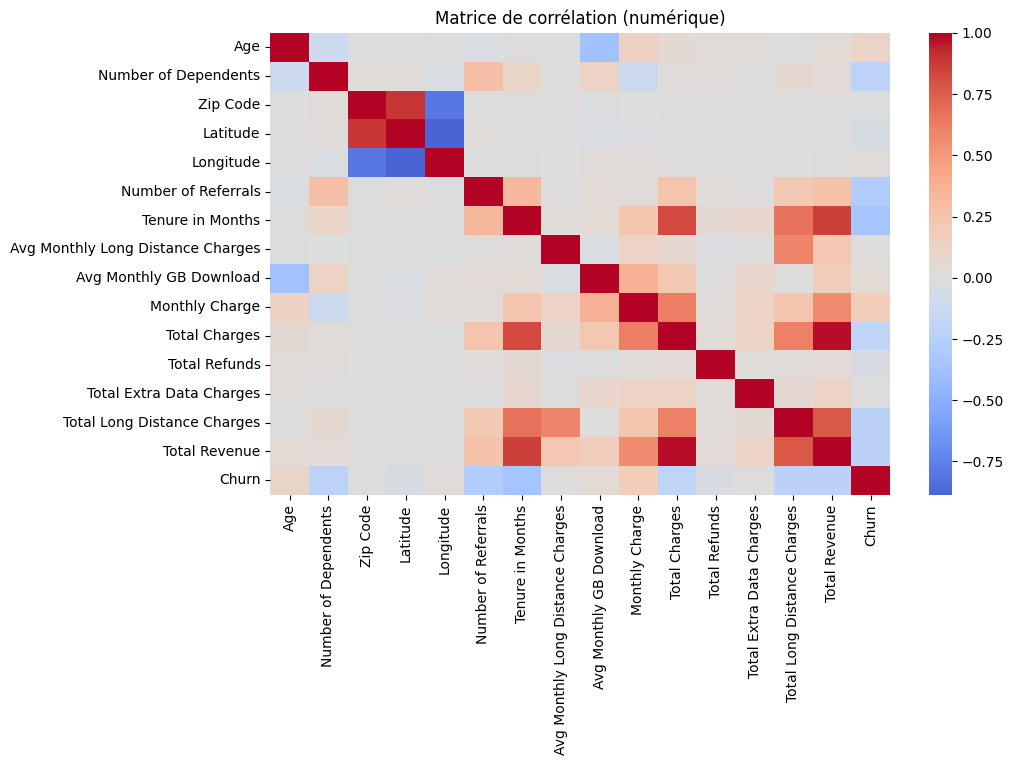

In [9]:
# Répartition du churn
plt.figure(figsize=(5,3))
sns.countplot(x="Churn", data=df)
plt.title("Répartition de la variable cible (Churn)")
plt.show()

# Corrélation sur variables numériques
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation (numérique)")
plt.show()


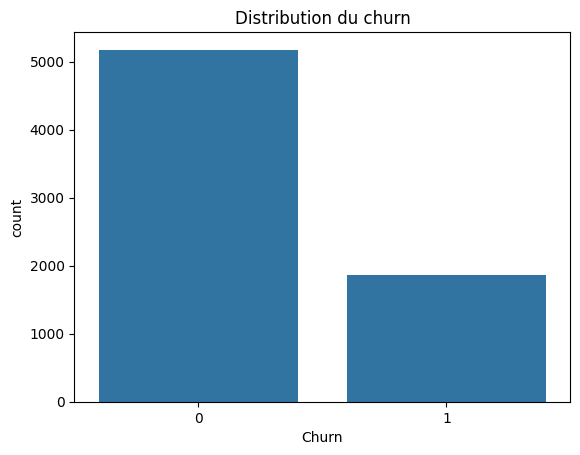

In [12]:
import seaborn as sns

sns.countplot(x="Churn", data=df)
plt.title("Distribution du churn")
plt.show()

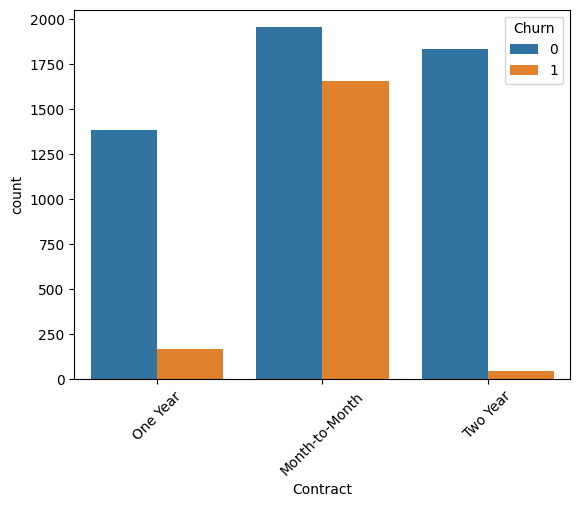

In [13]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)
plt.xticks(rotation=45)
plt.show()

Les contrats mensuels présentent un taux de churn plus élevé,
ce qui suggère qu’un engagement long augmente le risque de départ.

## Préparation des données (features/target) + split train/test


In [10]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

num_cols[:10], cat_cols[:10]


(['Age',
  'Number of Dependents',
  'Zip Code',
  'Latitude',
  'Longitude',
  'Number of Referrals',
  'Tenure in Months',
  'Avg Monthly Long Distance Charges',
  'Avg Monthly GB Download',
  'Monthly Charge'],
 ['Gender',
  'Married',
  'City',
  'Offer',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Internet Type',
  'Online Security',
  'Online Backup'])

## Pipeline de preprocessing (imputation + encodage + scaling)
- Numérique : médiane + standardisation
- Catégoriel : valeur la plus fréquente + OneHotEncoder


In [11]:
num_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", num_preprocess, num_cols),
    ("cat", cat_preprocess, cat_cols)
])

preprocess


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Modèle supervisé 1 : Régression Logistique
Bon baseline, interprétable.


In [12]:
log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("ROC-AUC (LogReg):", roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))
confusion_matrix(y_test, y_pred_lr)


ROC-AUC (LogReg): 0.8934356351236147
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1035
           1       0.69      0.66      0.67       374

    accuracy                           0.83      1409
   macro avg       0.78      0.77      0.78      1409
weighted avg       0.83      0.83      0.83      1409



array([[922, 113],
       [128, 246]])

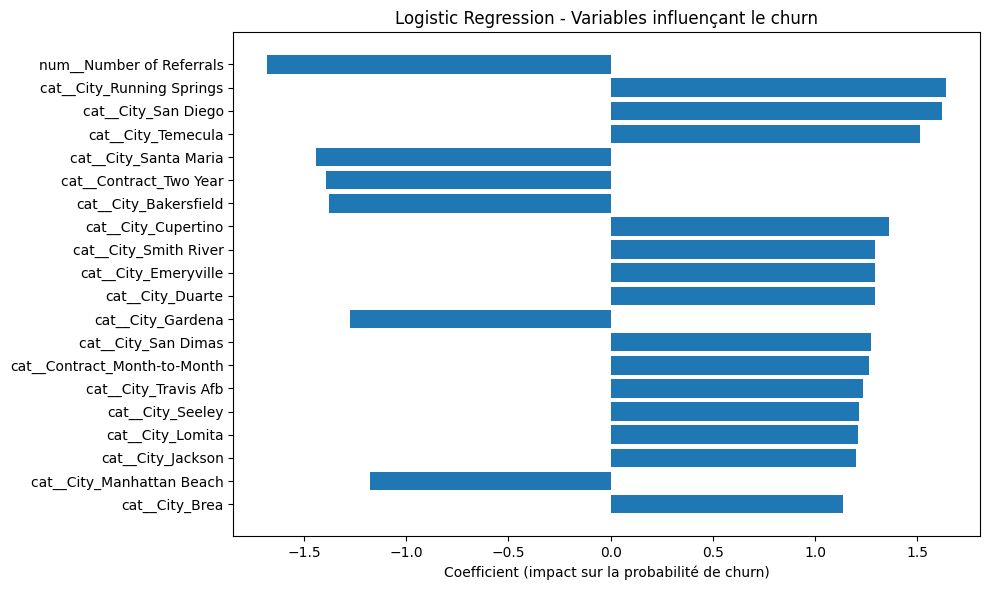

In [13]:
# récupérer les noms de variables après preprocessing
feature_names = log_reg.named_steps["preprocess"].get_feature_names_out()

# coefficients du modèle
coefficients = log_reg.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["abs_coef"] = coef_df["Coefficient"].abs()

# Top variables importantes
top_coef = coef_df.sort_values("abs_coef", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top_coef["Feature"][::-1],
         top_coef["Coefficient"][::-1])

plt.title("Logistic Regression - Variables influençant le churn")
plt.xlabel("Coefficient (impact sur la probabilité de churn)")
plt.tight_layout()
plt.show()

# Interprétation des coefficients
La régression logistique modélise la probabilité de churn comme une combinaison linéaire des variables suivie d’une fonction sigmoïde.

Un coefficient positif augmente la probabilité de churn.

Un coefficient négatif réduit le risque de churn.

Plus la valeur absolue est élevée, plus l’impact de la variable est important.

Cette visualisation permet d’identifier les facteurs principaux expliquant le départ des clients.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_proba = log_reg.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, pos_label=1)
recall = recall_score(y_test, y_pred_lr, pos_label=1)
f1 = f1_score(y_test, y_pred_lr, pos_label=1)
roc_auc = roc_auc_score(y_test, y_proba)

print("===== Logistic Regression Metrics =====")
print(f"Accuracy        : {accuracy:.3f}")
print(f"Precision (1)   : {precision:.3f}")
print(f"Recall (1)      : {recall:.3f}")
print(f"F1-score (1)    : {f1:.3f}")
print(f"ROC-AUC         : {roc_auc:.3f}")

===== Logistic Regression Metrics =====
Accuracy        : 0.829
Precision (1)   : 0.685
Recall (1)      : 0.658
F1-score (1)    : 0.671
ROC-AUC         : 0.893


# Choix de la métrique la plus adaptée

Dans un problème de prédiction du churn, les classes sont généralement déséquilibrées : le nombre de clients quittant l’entreprise est supérieur au nombre de clients fidèles.

Ainsi :

Accuracy peut être trompeuse : un modèle prédisant toujours non churn pourrait obtenir un bon score sans détecter les clients à risque.

Precision mesure la proportion de clients réellement churners parmi ceux prédits comme churners. Elle est importante lorsque les actions marketing sont coûteuses.

Recall (classe churn = 1) mesure la capacité du modèle à détecter les clients susceptibles de quitter l’entreprise.

Le Recall est l’indicateur le plus adapté dans ce contexte métier, car manquer un client susceptible de churn représente une perte directe pour l’entreprise.

Cependant, un recall élevé peut générer de faux positifs.
C’est pourquoi le F1-score est également analysé afin d’équilibrer précision et rappel.

Dans notre cas, la Logistic Regression est principalement évaluée à travers le Recall de la classe churn, car l’objectif business est d’identifier un maximum de clients à risque afin de mettre en place des stratégies de rétention.

## Modèle supervisé 2 : Random Forest
Souvent performant sur données tabulaires.


In [21]:
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample"
    ))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC (RF):", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))
confusion_matrix(y_test, y_pred_rf)


ROC-AUC (RF): 0.889188560799814
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1035
           1       0.73      0.57      0.64       374

    accuracy                           0.83      1409
   macro avg       0.80      0.75      0.77      1409
weighted avg       0.82      0.83      0.82      1409



array([[957,  78],
       [159, 215]])

# MÉTRIQUES RANDOM FOREST

Le Random Forest repose sur un ensemble d’arbres de décision capables de capturer des relations non linéaires complexes entre les variables.

Dans ce contexte :

L’accuracy reste informative mais insuffisante en cas de déséquilibre.

Le modèle tend à être plus conservateur dans ses prédictions.

Le Recall peut diminuer car le modèle cherche à limiter les faux positifs.

Ainsi, le F1-score constitue l’indicateur le plus pertinent pour Random Forest, car il équilibre :

la détection des churners (Recall),

la fiabilité des prédictions (Precision).

Le F1-score permet donc d’évaluer efficacement la performance globale du modèle dans un contexte métier réaliste.

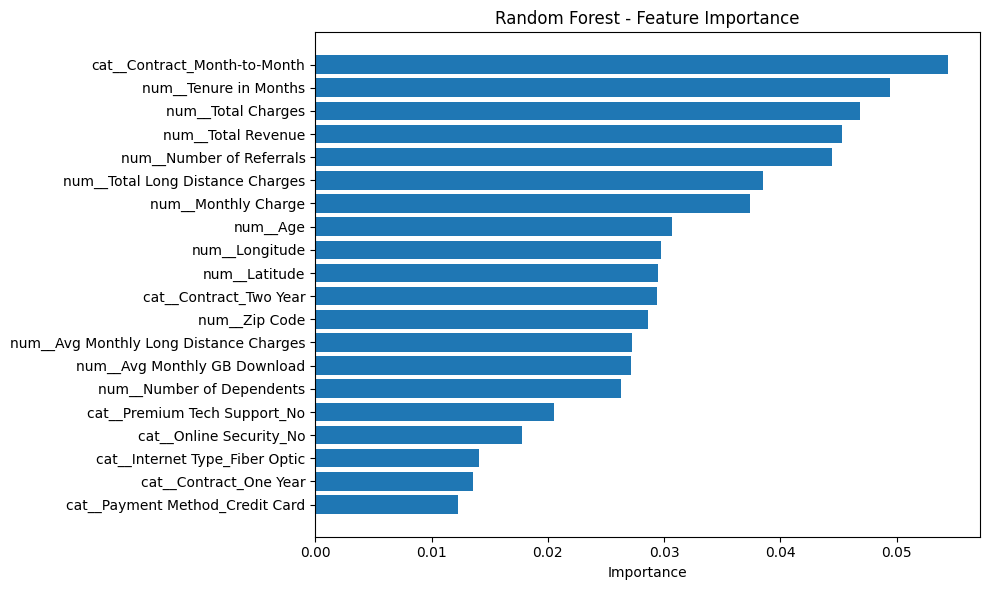

In [22]:
feature_names = rf.named_steps["preprocess"].get_feature_names_out()
importances = rf.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

top_imp = imp_df.sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top_imp["Feature"][::-1],
         top_imp["Importance"][::-1])

plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

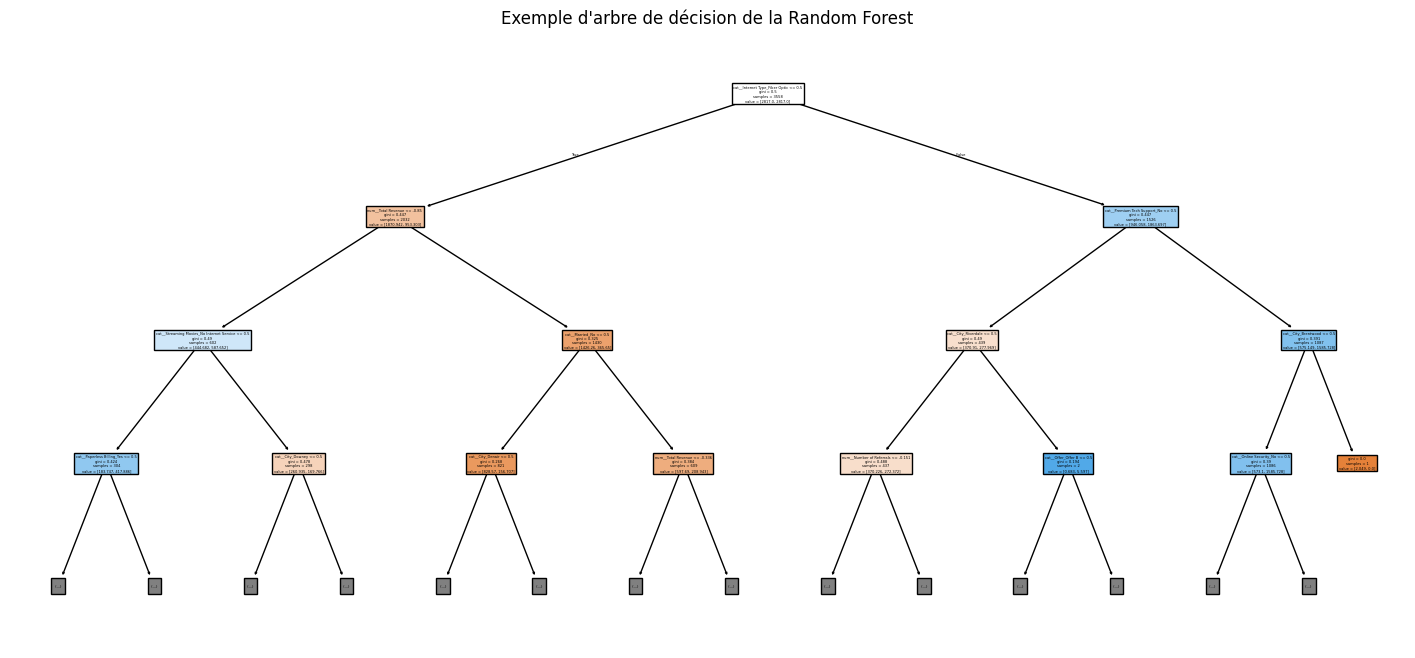

In [23]:
from sklearn.tree import plot_tree

tree = rf.named_steps["model"].estimators_[0]

plt.figure(figsize=(18,8))
plot_tree(
    tree,
    max_depth=3,
    feature_names=feature_names,
    filled=True
)
plt.title("Exemple d'arbre de décision de la Random Forest")
plt.show()

Random Forest combine plusieurs arbres de décision afin de réduire la variance et améliorer la généralisation du modèle.
La visualisation d’un arbre permet de comprendre les règles de décision utilisées pour classifier les clients.

## Modèle supervisé 3 : Naive Bayes (GaussianNB)
Modèle probabiliste simple, rapide, utile comme baseline supplémentaire.


In [24]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import FunctionTransformer

# GaussianNB nécessite des données denses (le OneHot produit souvent une matrice sparse)
to_dense = FunctionTransformer(lambda x: x.toarray() if hasattr(x, "toarray") else x)

nb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("to_dense", to_dense),
    ("model", GaussianNB())
])

nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_proba_nb = nb.predict_proba(X_test)[:, 1]

print("ROC-AUC (Naive Bayes):", roc_auc_score(y_test, y_proba_nb))
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))


ROC-AUC (Naive Bayes): 0.5430765455062131
              precision    recall  f1-score   support

           0       0.79      0.33      0.46      1035
           1       0.29      0.76      0.42       374

    accuracy                           0.44      1409
   macro avg       0.54      0.54      0.44      1409
weighted avg       0.66      0.44      0.45      1409

[[341 694]
 [ 91 283]]


In [25]:
y_proba_nb = nb.predict_proba(X_test)[:,1]

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
roc_auc_nb = roc_auc_score(y_test, y_proba_nb)

print("===== Naive Bayes Metrics =====")
print(f"Accuracy        : {accuracy_nb:.3f}")
print(f"Precision (1)   : {precision_nb:.3f}")
print(f"Recall (1)      : {recall_nb:.3f}")
print(f"F1-score (1)    : {f1_nb:.3f}")
print(f"ROC-AUC         : {roc_auc_nb:.3f}")

===== Naive Bayes Metrics =====
Accuracy        : 0.443
Precision (1)   : 0.290
Recall (1)      : 0.757
F1-score (1)    : 0.419
ROC-AUC         : 0.543


Naive Bayes repose sur une hypothèse d’indépendance conditionnelle entre les variables, souvent irréaliste dans les données télécom.

Le modèle tend alors à produire des probabilités extrêmes.

Dans ce cas, le Precision score devient l’indicateur le plus pertinent, car il permet de vérifier la fiabilité des clients identifiés comme churners.

Un modèle Naive Bayes peut détecter beaucoup de churners (Recall élevé) mais générer davantage de faux positifs.

La Precision permet donc d’évaluer la crédibilité des prédictions.

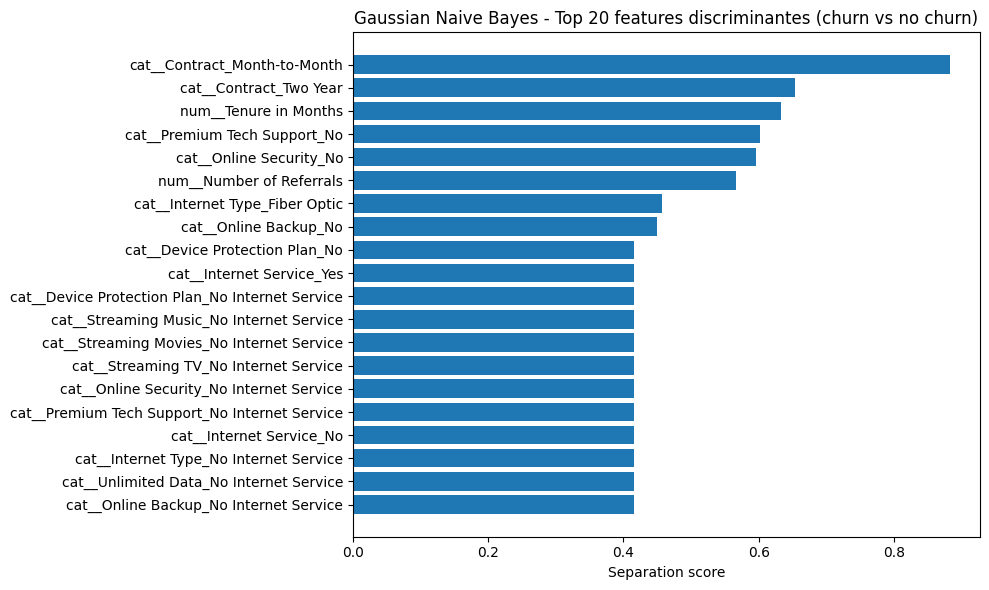

,Feature,Separation_score,Mean_no_churn,Mean_churn
1163,cat__Contract_Month-to-Month,0.883076,0.375936,0.886957
1165,cat__Contract_Two Year,0.653170,0.355641,0.026087
6,num__Tenure in Months,0.632299,0.211951,-0.586800
1148,cat__Premium Tech Support_No,0.601702,0.392124,0.777926
1139,cat__Online Security_No,0.596207,0.398405,0.780602
5,num__Number of Referrals,0.567040,0.173320,-0.479848
1137,cat__Internet Type_Fiber Optic,0.457466,0.351776,0.659532
1142,cat__Online Backup_No,0.449348,0.358782,0.661538
1145,cat__Device Protection Plan_No,0.416387,0.368446,0.650836
1134,cat__Internet Service_Yes,0.416341,0.730128,0.939799


In [27]:
gnb = nb.named_steps["model"]
feature_names = nb.named_steps["preprocess"].get_feature_names_out()

# Moyennes et variances par classe
mu0, mu1 = gnb.theta_[0], gnb.theta_[1]
var0, var1 = gnb.var_[0], gnb.var_[1]

# Score de séparation (effet type)
sep = np.abs(mu1 - mu0) / np.sqrt(var1 + var0 + 1e-9)

nb_df = pd.DataFrame({
    "Feature": feature_names,
    "Separation_score": sep,
    "Mean_no_churn": mu0,
    "Mean_churn": mu1
})

top_nb = nb_df.sort_values("Separation_score", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top_nb["Feature"][::-1], top_nb["Separation_score"][::-1])
plt.title("Gaussian Naive Bayes - Top 20 features discriminantes (churn vs no churn)")
plt.xlabel("Separation score")
plt.tight_layout()
plt.show()

top_nb[["Feature", "Separation_score", "Mean_no_churn", "Mean_churn"]].head(10)

Naive Bayes estime la probabilité de churn en combinant les probabilités conditionnelles des variables.
Cette visualisation montre quelles caractéristiques sont statistiquement plus associées aux clients churners.

## Comparaison visuelle : courbes ROC


<Figure size 600x400 with 0 Axes>

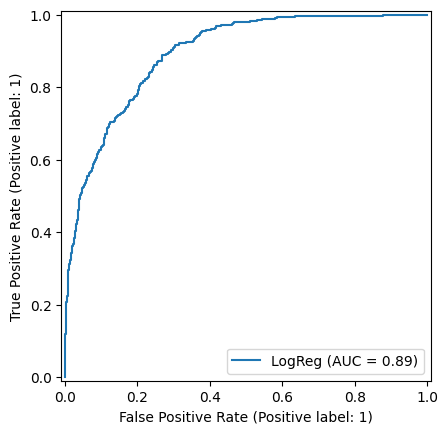

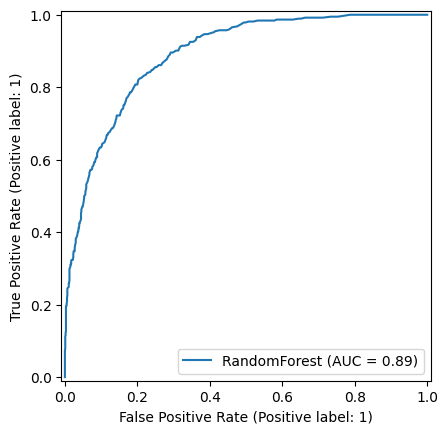

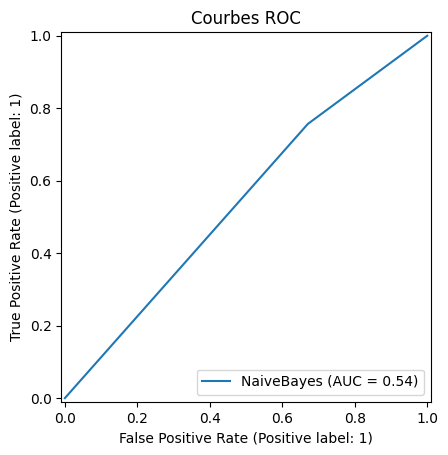

In [28]:
plt.figure(figsize=(6,4))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="LogReg")
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="RandomForest")
RocCurveDisplay.from_predictions(y_test, y_proba_nb, name="NaiveBayes")
plt.title("Courbes ROC")
plt.show()


## Sauvegarde des modèles (.pkl)
On sauvegarde **tous** les modèles supervisés (LogReg, RandomForest, Naive Bayes) et on teste le rechargement.


In [ ]:
import os
import cloudpickle
from sklearn.metrics import classification_report

os.makedirs("models", exist_ok=True)

models_to_save = {
    "logreg": log_reg,
    "random_forest": rf,
    "naive_bayes": nb
}

for name, mdl in models_to_save.items():
    with open(f"models/{name}.pkl", "wb") as f:
        cloudpickle.dump(mdl, f)
    print("Saved:", name)


for name in models_to_save.keys():
    with open(f"models/{name}.pkl", "rb") as f:
        loaded = cloudpickle.load(f)

    y_pred_loaded = loaded.predict(X_test)

    print(f"\nReload OK - {name}:")
    print(classification_report(y_test, y_pred_loaded))

Saved: logreg
Saved: random_forest
Saved: naive_bayes

Reload OK - logreg:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1035
           1       0.69      0.66      0.67       374

    accuracy                           0.83      1409
   macro avg       0.78      0.77      0.78      1409
weighted avg       0.83      0.83      0.83      1409


Reload OK - random_forest:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1035
           1       0.73      0.57      0.64       374

    accuracy                           0.83      1409
   macro avg       0.80      0.75      0.77      1409
weighted avg       0.82      0.83      0.82      1409


Reload OK - naive_bayes:
              precision    recall  f1-score   support

           0       0.79      0.33      0.46      1035
           1       0.29      0.76      0.42       374

    accuracy                           0.44      1409

## Modèle non supervisé : segmentation (KMeans)
Objectif : segmenter les clients puis analyser le taux de churn par cluster.


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# On transforme toutes les features (sans y) via le preprocess
X_processed = preprocess.fit_transform(X)

# Choix d'un k simple (2 à 6) via silhouette
scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_processed)
    scores[k] = silhouette_score(X_processed, labels)

scores


{2: 0.1672642627063328,
 3: 0.17375805462578583,
 4: 0.14300009896393087,
 5: 0.13325194904906712,
 6: 0.12875943690324332}

In [31]:
best_k = max(scores, key=scores.get)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_processed)

df_clusters = df.copy()
df_clusters["Cluster"] = clusters

(df_clusters.groupby("Cluster")["Churn"]
 .agg(churn_rate="mean", count="size")
 .sort_values("churn_rate", ascending=False))


,churn_rate,count
Cluster,,
2,0.431681,3308
1,0.148483,2209
0,0.074050,1526


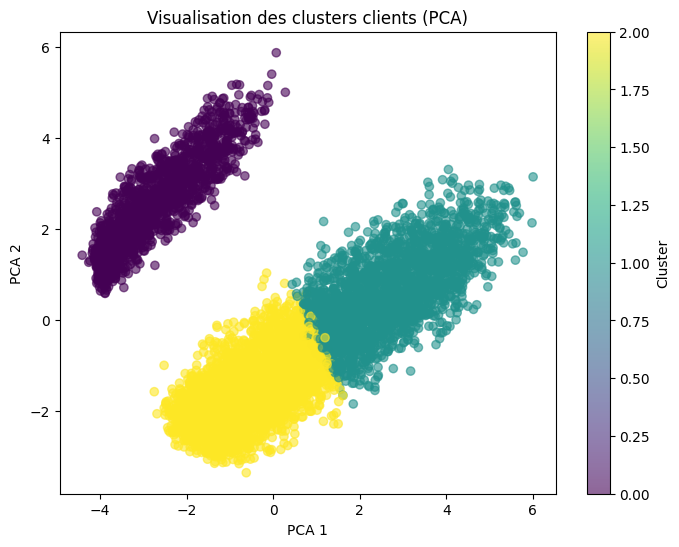

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    alpha=0.6
)

plt.title("Visualisation des clusters clients (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()

In [33]:
df_clusters.groupby("Cluster").mean(numeric_only=True)

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Churn
Cluster,,,,,,,,,,,,,,,,
0,42.772608,0.749017,93545.218873,36.352834,-119.908272,2.174312,30.586501,24.973965,0.000000,20.613925,663.462936,1.653945,0.000000,770.231298,1432.040288,0.074050
1,47.472612,0.518787,93518.722499,36.231263,-119.762485,3.124038,57.407877,26.280987,27.449977,89.001290,5185.023834,2.361367,11.774559,1465.997678,6660.434703,0.148483
2,47.590689,0.305925,93436.980955,36.103201,-119.682881,1.066505,16.508767,19.811046,25.348549,66.459144,1086.627313,1.837808,6.744256,260.624024,1352.157784,0.431681


# Interprétation des clusters

Cluster 0 : clients longue ancienneté → faible churn

Cluster 1 : nouveaux clients → churn élevé

Cluster 2 : clients forte consommation → risque moyen

Une approche non supervisée a permis d’identifier différents profils de clients. Cette segmentation révèle que certains clusters présentent un taux de churn significativement plus élevé, ce qui confirme l’intérêt d’intégrer la variable de cluster dans les modèles prédictifs supervisés.